# Logistics Demand Prediction using Regression

## Project Objective

The objective of this project is to predict the daily demand of logistics items
using historical inventory, reorder, lead-time, demand variability and popularity
related features.

The project follows an end-to-end Machine Learning Regression workflow:

- Data Loading
- Data Understanding
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Feature Scaling
- Train-Test Split
- Regression Model Building
- Model Evaluation
- Model Comparison
- Best Model Selection
- Model Saving
- Prediction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")



In [7]:
data= pd.read_csv("logistics_dataset-selected-columns.csv")

data

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36
...,...,...,...,...,...,...,...,...,...,...
3199,ITM13199,Groceries,343,21,12,2,39.88,1.30,0.34,L43
3200,ITM13200,Electronics,428,43,5,7,2.68,4.25,0.91,L83
3201,ITM13201,Groceries,415,80,14,5,49.15,5.41,0.14,L11
3202,ITM13202,Groceries,173,84,3,9,43.39,8.47,0.69,L58


In [8]:
data.head()

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36


In [9]:
data.tail()

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id
3199,ITM13199,Groceries,343,21,12,2,39.88,1.30,0.34,L43
3200,ITM13200,Electronics,428,43,5,7,2.68,4.25,0.91,L83
3201,ITM13201,Groceries,415,80,14,5,49.15,5.41,0.14,L11
3202,ITM13202,Groceries,173,84,3,9,43.39,8.47,0.69,L58
3203,ITM13203,Apparel,377,40,14,3,29.40,7.43,0.14,L48


In [10]:
data.sample(7, random_state=42)

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id
610,ITM10610,Electronics,101,33,10,8,9.58,5.10,0.22,L71
3047,ITM13047,Automotive,354,32,4,5,32.93,6.53,0.48,L45
2724,ITM12724,Pharma,484,72,14,2,12.60,4.29,0.18,L62
1913,ITM11913,Groceries,402,34,14,4,48.30,7.96,0.63,L19
2882,ITM12882,Apparel,125,15,9,5,11.07,8.78,0.28,L64
495,ITM10495,Electronics,203,79,13,8,33.73,1.45,0.10,L14
807,ITM10807,Groceries,186,63,14,3,6.16,2.74,0.83,L3


In [12]:
data.shape

(3204, 10)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   item_id                 3204 non-null   str    
 1   category                3204 non-null   str    
 2   stock_level             3204 non-null   int64  
 3   reorder_point           3204 non-null   int64  
 4   reorder_frequency_days  3204 non-null   int64  
 5   lead_time_days          3204 non-null   int64  
 6   daily_demand            3204 non-null   float64
 7   demand_std_dev          3204 non-null   float64
 8   item_popularity_score   3204 non-null   float64
 9   storage_location_id     3204 non-null   str    
dtypes: float64(3), int64(4), str(3)
memory usage: 311.6 KB


In [14]:
df.isnull().sum()

item_id                   0
category                  0
stock_level               0
reorder_point             0
reorder_frequency_days    0
lead_time_days            0
daily_demand              0
demand_std_dev            0
item_popularity_score     0
storage_location_id       0
dtype: int64

In [16]:
duplicate_data = df[df.duplicated()]

duplicate_data
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [17]:
df.describe()

,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score
count,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000
mean,263.491573,54.759363,8.507803,5.578340,25.435868,5.260078,0.542325
std,138.568360,26.053354,3.473229,2.292486,14.038861,2.725639,0.259200
min,20.000000,10.000000,3.000000,2.000000,1.010000,0.500000,0.100000
25%,144.000000,32.000000,5.000000,4.000000,13.535000,2.917500,0.310000
50%,264.000000,55.000000,9.000000,6.000000,25.405000,5.235000,0.540000
75%,386.000000,78.000000,12.000000,8.000000,37.412500,7.542500,0.760000
max,499.000000,99.000000,14.000000,9.000000,49.980000,10.000000,1.000000


In [18]:
df.describe(include="object")

,item_id,category,storage_location_id
count,3204,3204,3204
unique,3204,5,100
top,ITM10000,Pharma,L59
freq,1,660,41


### Category Distribution

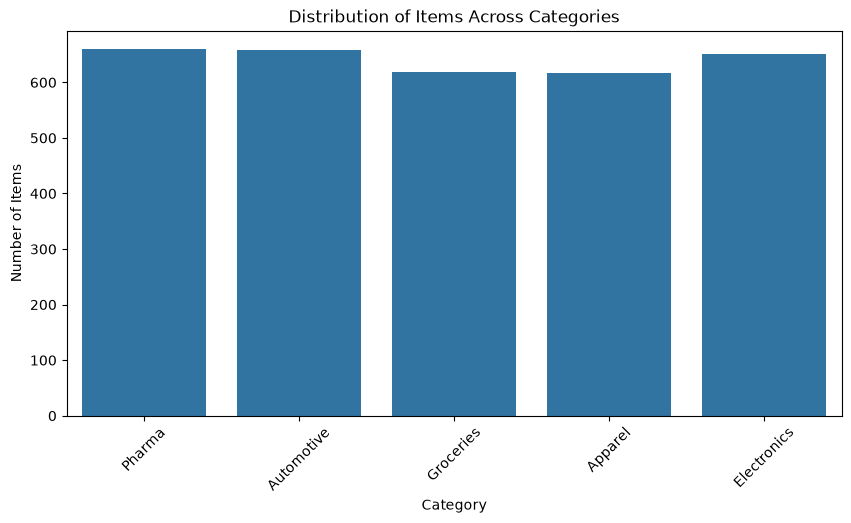

In [19]:
plt.figure(figsize=(10, 5))

sns.countplot(x="category", data=df)

plt.xlabel("Category")
plt.ylabel("Number of Items")
plt.title("Distribution of Items Across Categories")

plt.xticks(rotation=45)
plt.show()

### Daily Demand Distribution

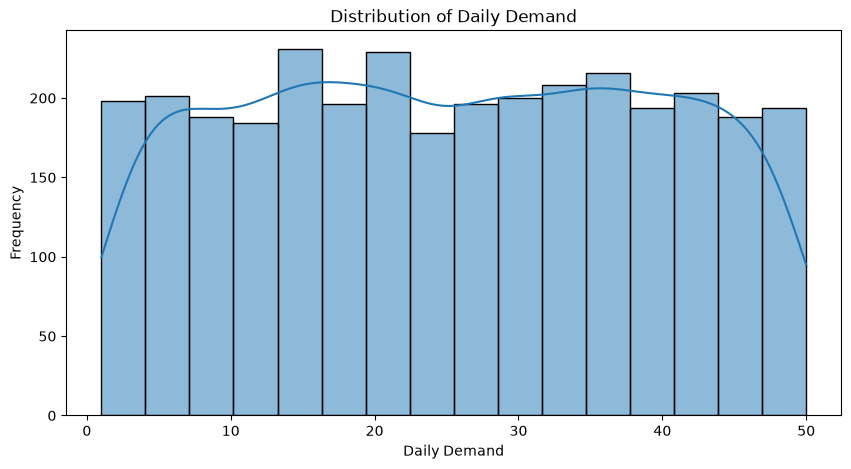

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(df["daily_demand"], kde=True)

plt.xlabel("Daily Demand")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Demand")

plt.show()

### Daily Demand Boxplot

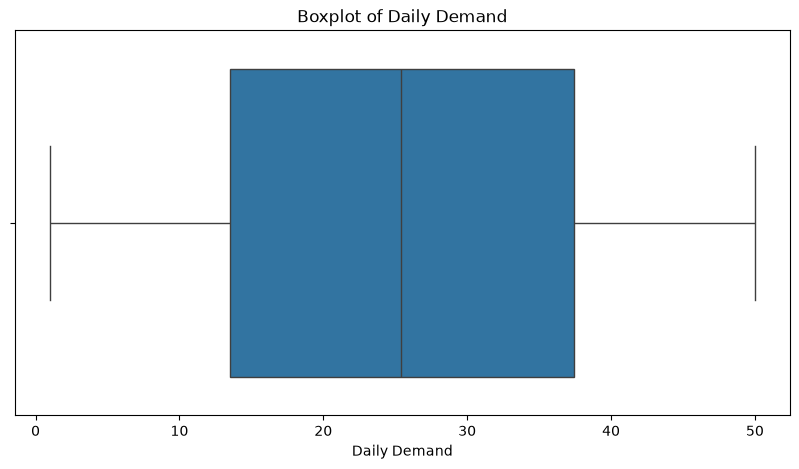

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["daily_demand"])

plt.xlabel("Daily Demand")
plt.title("Boxplot of Daily Demand")

plt.show()

### Average Demand by Category

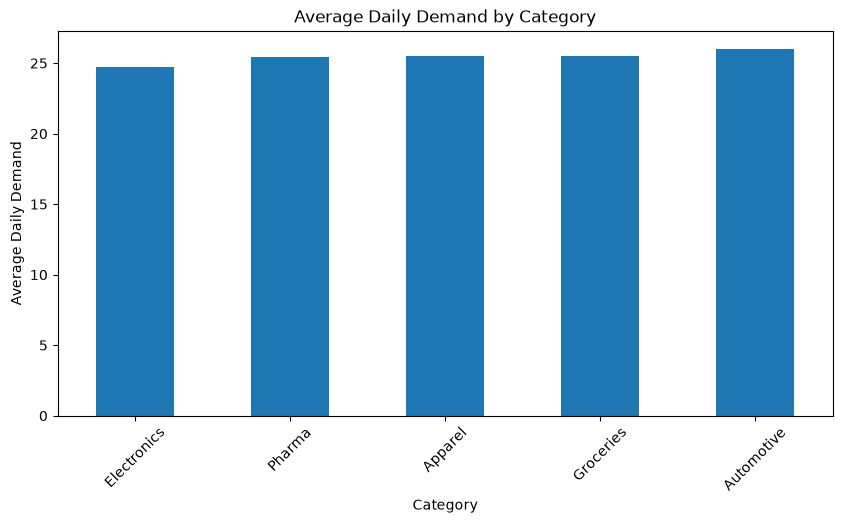

In [22]:
plt.figure(figsize=(10, 5))

df.groupby("category")["daily_demand"].mean().sort_values().plot.bar()

plt.xlabel("Category")
plt.ylabel("Average Daily Demand")
plt.title("Average Daily Demand by Category")

plt.xticks(rotation=45)
plt.show()

### Demand vs Stock Level

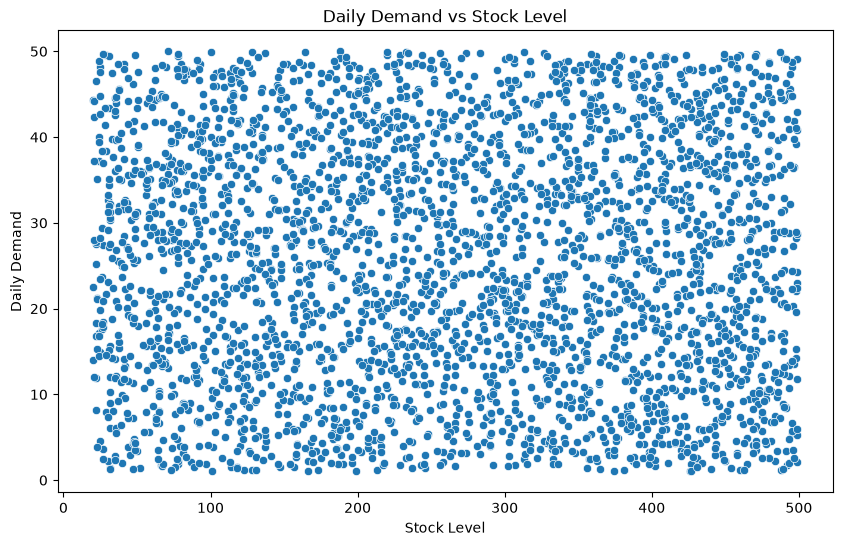

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="stock_level",
    y="daily_demand",
    data=df
)

plt.xlabel("Stock Level")
plt.ylabel("Daily Demand")
plt.title("Daily Demand vs Stock Level")

plt.show()

### Demand vs Popularity

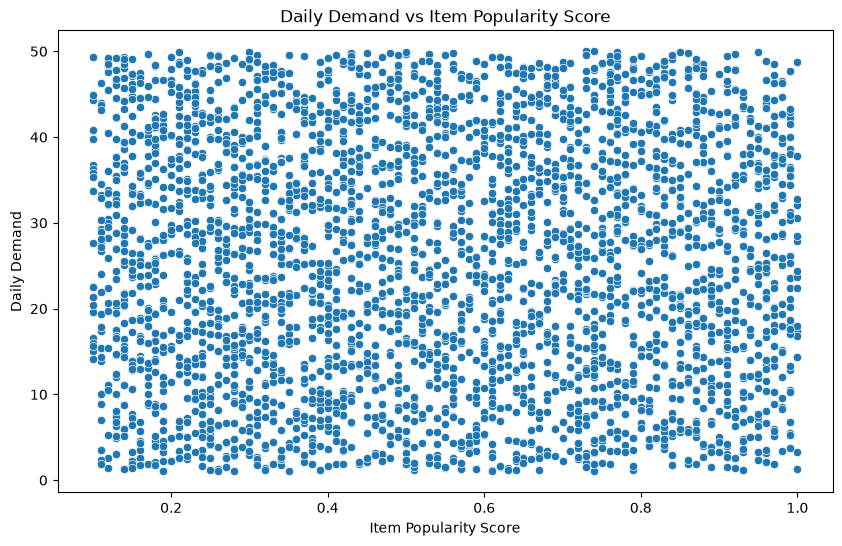

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="item_popularity_score",
    y="daily_demand",
    data=df
)

plt.xlabel("Item Popularity Score")
plt.ylabel("Daily Demand")
plt.title("Daily Demand vs Item Popularity Score")

plt.show()

### correalation

In [25]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score
stock_level,1.000000,-0.037787,-0.025615,-0.006148,-0.019264,-0.012204,0.004142
reorder_point,-0.037787,1.000000,-0.000329,-0.003633,-0.013884,0.016983,0.024654
reorder_frequency_days,-0.025615,-0.000329,1.000000,0.015333,0.025691,0.019171,0.004400
lead_time_days,-0.006148,-0.003633,0.015333,1.000000,-0.003615,-0.009319,-0.019067
daily_demand,-0.019264,-0.013884,0.025691,-0.003615,1.000000,-0.005187,0.002950
demand_std_dev,-0.012204,0.016983,0.019171,-0.009319,-0.005187,1.000000,0.001391
item_popularity_score,0.004142,0.024654,0.004400,-0.019067,0.002950,0.001391,1.000000


### Correlation Heatmap

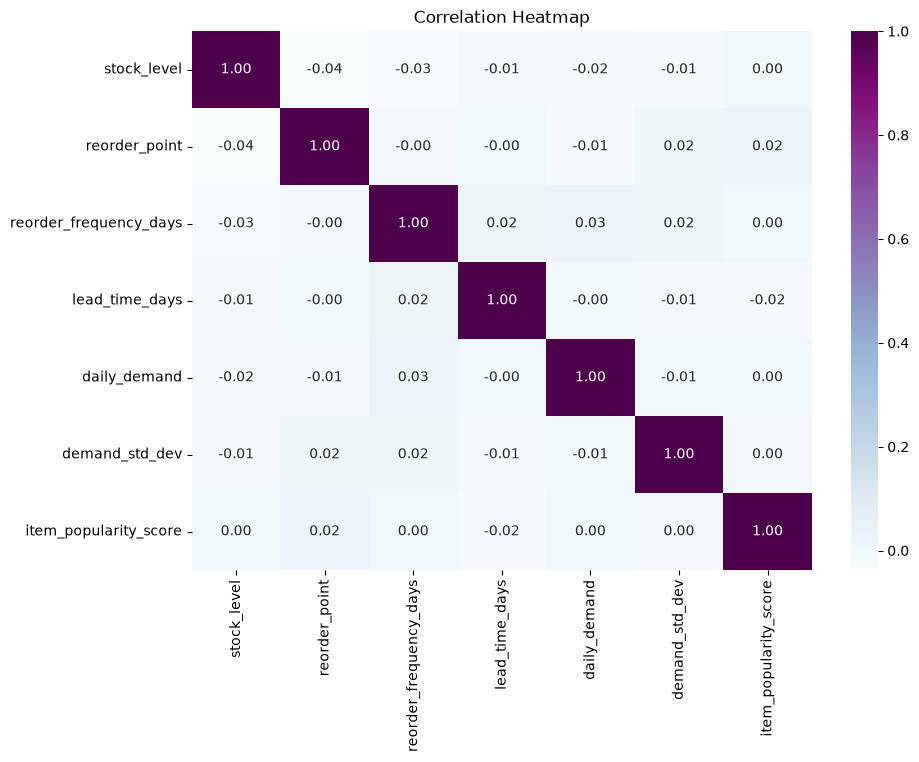

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="BuPu",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Feature Preparation

In [28]:
# Target variable
y = df["daily_demand"]

# Features
X = df.drop(columns=["daily_demand", "item_id"])

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("daily_demand")

Features:
['category', 'stock_level', 'reorder_point', 'reorder_frequency_days', 'lead_time_days', 'demand_std_dev', 'item_popularity_score', 'storage_location_id']

Target:
daily_demand


## categorical columns

In [29]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['category', 'storage_location_id']


## numerical columns

In [30]:
numerical_columns = X.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['stock_level', 'reorder_point', 'reorder_frequency_days', 'lead_time_days', 'demand_std_dev', 'item_popularity_score']


### onehot encoding

In [31]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

X_encoded.head()

,stock_level,reorder_point,reorder_frequency_days,lead_time_days,demand_std_dev,item_popularity_score,category_Automotive,category_Electronics,category_Groceries,category_Pharma,...,storage_location_id_L90,storage_location_id_L91,storage_location_id_L92,storage_location_id_L93,storage_location_id_L94,storage_location_id_L95,storage_location_id_L96,storage_location_id_L97,storage_location_id_L98,storage_location_id_L99
0,283,21,4,4,1.56,0.43,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,301,52,9,6,2.55,0.69,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,132,60,11,8,3.15,0.62,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,346,46,13,5,2.79,0.21,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,49,55,4,6,5.23,0.31,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
print("Original number of features:", X.shape[1])
print("Number of features after encoding:", X_encoded.shape[1])

print("\nFinal feature names:")
print(X_encoded.columns.tolist())

Original number of features: 8
Number of features after encoding: 109

Final feature names:
['stock_level', 'reorder_point', 'reorder_frequency_days', 'lead_time_days', 'demand_std_dev', 'item_popularity_score', 'category_Automotive', 'category_Electronics', 'category_Groceries', 'category_Pharma', 'storage_location_id_L10', 'storage_location_id_L100', 'storage_location_id_L11', 'storage_location_id_L12', 'storage_location_id_L13', 'storage_location_id_L14', 'storage_location_id_L15', 'storage_location_id_L16', 'storage_location_id_L17', 'storage_location_id_L18', 'storage_location_id_L19', 'storage_location_id_L2', 'storage_location_id_L20', 'storage_location_id_L21', 'storage_location_id_L22', 'storage_location_id_L23', 'storage_location_id_L24', 'storage_location_id_L25', 'storage_location_id_L26', 'storage_location_id_L27', 'storage_location_id_L28', 'storage_location_id_L29', 'storage_location_id_L3', 'storage_location_id_L30', 'storage_location_id_L31', 'storage_location_id_L32',

## train test split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2563, 109)
X_test shape: (641, 109)
y_train shape: (2563,)
y_test shape: (641,)


## Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [35]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Number of features:", X_train.shape[1])

Training samples: 2563
Testing samples: 641
Number of features: 109


## regression models

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Regression models imported successfully!")

Regression models imported successfully!


## linear regression

In [37]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## svr

In [38]:
svr_model = SVR()

svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

print("Support Vector Regression model trained successfully!")

Support Vector Regression model trained successfully!


## decsion tree

In [39]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


## random forest

In [40]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


## gradient boosting

In [41]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Regression model trained successfully!")

Gradient Boosting Regression model trained successfully!


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
# Linear Regression
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

# Support Vector Regression
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_pred)

# Decision Tree
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

# Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

# Gradient Boosting
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

In [45]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "MAE": [
        linear_mae,
        svr_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        linear_mse,
        svr_mse,
        dt_mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        linear_rmse,
        svr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        linear_r2,
        svr_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,12.603260,212.762772,14.586390,-0.042438
1,Support Vector Regression,12.445668,206.329432,14.364172,-0.010917
2,Decision Tree Regression,16.256037,406.662793,20.165882,-0.992457
3,Random Forest Regression,12.881949,223.112857,14.936963,-0.093148
4,Gradient Boosting Regression,12.583935,211.546516,14.544639,-0.036479


In [46]:
results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

,Model,MAE,MSE,RMSE,R2 Score
0,Support Vector Regression,12.445668,206.329432,14.364172,-0.010917
1,Gradient Boosting Regression,12.583935,211.546516,14.544639,-0.036479
2,Linear Regression,12.603260,212.762772,14.586390,-0.042438
3,Random Forest Regression,12.881949,223.112857,14.936963,-0.093148
4,Decision Tree Regression,16.256037,406.662793,20.165882,-0.992457


## Model Comparison + Best Model + Graphs

                          Model        MAE         MSE       RMSE  R2 Score
0     Support Vector Regression  12.445668  206.329432  14.364172 -0.010917
1  Gradient Boosting Regression  12.583935  211.546516  14.544639 -0.036479
2             Linear Regression  12.603260  212.762772  14.586390 -0.042438
3      Random Forest Regression  12.881949  223.112857  14.936963 -0.093148
4      Decision Tree Regression  16.256037  406.662793  20.165882 -0.992457

Best Performing Model: Support Vector Regression
Best R2 Score: -0.01091748167199258


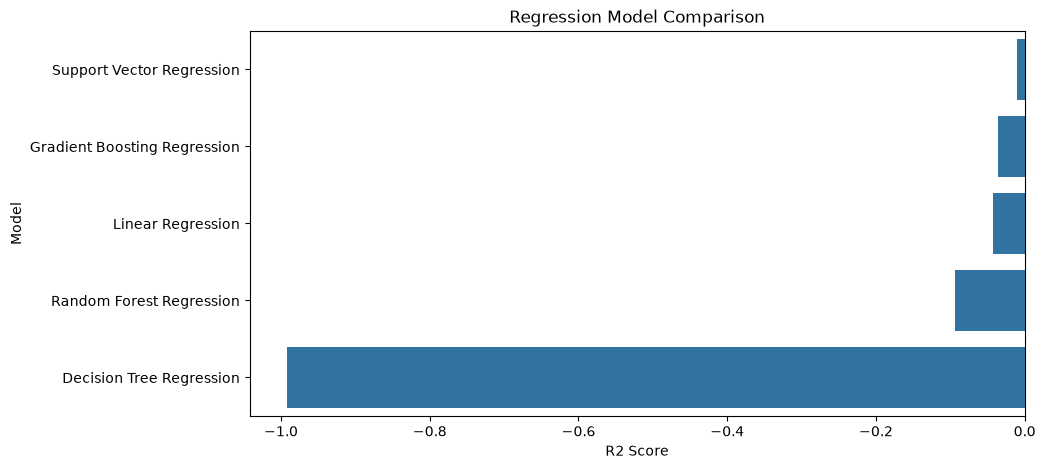

In [47]:
# Model comparison
results = results.sort_values("R2 Score", ascending=False).reset_index(drop=True)

print(results)

# Best model
best_model_name = results.loc[0, "Model"]
best_r2 = results.loc[0, "R2 Score"]

print("\nBest Performing Model:", best_model_name)
print("Best R2 Score:", best_r2)

# R2 comparison
plt.figure(figsize=(10, 5))
sns.barplot(x="R2 Score", y="Model", data=results)
plt.title("Regression Model Comparison")
plt.show()

##  Actual vs Predicted + Residual Plot

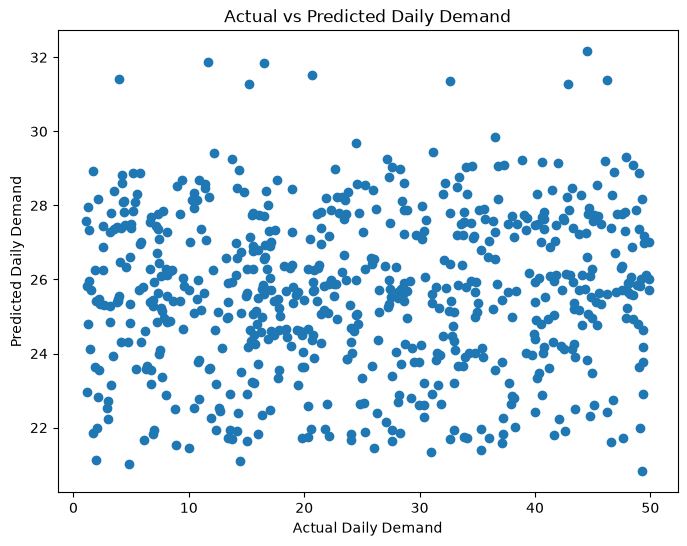

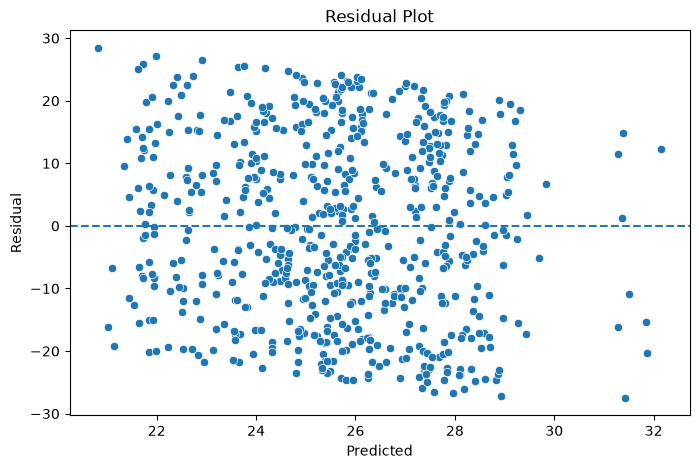

In [48]:
predictions = {
    "Linear Regression": linear_pred,
    "Support Vector Regression": svr_pred,
    "Decision Tree Regression": dt_pred,
    "Random Forest Regression": rf_pred,
    "Gradient Boosting Regression": gb_pred
}

best_pred = predictions[best_model_name]

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_pred
})

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(comparison["Actual"], comparison["Predicted"])
plt.xlabel("Actual Daily Demand")
plt.ylabel("Predicted Daily Demand")
plt.title("Actual vs Predicted Daily Demand")
plt.show()

# Residual
comparison["Residual"] = comparison["Actual"] - comparison["Predicted"]

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Predicted", y="Residual", data=comparison)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.show()

## saving best model

In [49]:
import pickle

best_model = {
    "Linear Regression": linear_model,
    "Support Vector Regression": svr_model,
    "Decision Tree Regression": dt_model,
    "Random Forest Regression": rf_model,
    "Gradient Boosting Regression": gb_model
}[best_model_name]

with open("logistics_best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("logistics_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Best model:", best_model_name)
print("Model saved successfully!")

Best model: Support Vector Regression
Model saved successfully!


In [51]:
import pickle

best_model = {
    "Linear Regression": linear_model,
    "Support Vector Regression": svr_model,
    "Decision Tree Regression": dt_model,
    "Random Forest Regression": rf_model,
    "Gradient Boosting Regression": gb_model
}[best_model_name]

with open("logistics_best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("logistics_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save feature columns used during training
with open("logistics_features.pkl", "wb") as file:
    pickle.dump(X_train.columns.tolist(), file)

print("Model, scaler and features saved successfully!")

Model, scaler and features saved successfully!
